In [ ]:
"""Calibratron runner.

Discovers an Ambit, dumps its config, then runs the PAR-sensor and actinic-LED
calibrations against reference instruments on the bench.

The calibration steps need extra hardware connected:
  - a Kiprim DC source            -> answers "KIPRIM"  to "*IDN?"
  - a MiniPAR used as PAR reference -> answers "Par_REF" to "get_name"
  - a MiniPAR over the actinic LED  -> answers "Emit_LED" to "get_name"
Whatever isn't connected is reported and that calibration step is skipped, so
the script is still useful with only the Ambit plugged in.
"""

import os, sys, subprocess, time, importlib
import numpy as np
import helpers; importlib.reload(helpers)


def save_payload(payload, mac=None, directory="./calibrations"):
    """Write the calibration payload to '<YYYY-MM-DD_HH-MM-SS>_<MAC>.json'.

    :param payload: the JSON string (or dict) from helpers.make_calibration_payload
    :param mac: device MAC for the filename; if None, read from payload["device_id"]
    :param directory: target folder (created if missing); defaults to ./calibrations
    :return: the path of the file written
    """
    import json
    from datetime import datetime
    data = json.loads(payload) if isinstance(payload, str) else payload
    text = payload if isinstance(payload, str) else json.dumps(payload, indent=2)
    mac  = mac or data.get("device_id") or "UNKNOWN"
    fname = f"{datetime.now():%Y-%m-%d_%H-%M-%S}_{mac}.json"
    os.makedirs(directory, exist_ok=True)
    path = os.path.join(directory, fname)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)
    print(f"[save] wrote {path}")
    return path

In [3]:
# 1. Discover the Ambit (retry once)
port_ambit = helpers.findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)
if port_ambit is None:
    port_ambit = helpers.findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)
if port_ambit is None:
    raise SystemExit("No Ambit device found on any serial port")


[helpers] Found device at: COM12


In [ ]:
# 1.1 Blink the ambit for sanity check
for i in range(3):
    helpers.set_ambit_led(port_ambit, 100)   
    time.sleep(0.1)
    helpers.set_ambit_led(port_ambit, 0)   
    time.sleep(0.1)


In [18]:
# 2. Reboot the device and parse its config dump into an AmbitInfo
info_precalibration = helpers.ambit_reboot(port_ambit)
print(info_precalibration)

FW: b'0.0.5' (MAC=48544fa89110, size=544640B, date=Mar  5 2026)
Name: b'AmbitTest', valid: True
Calibration: Spec(light_slope)=0.3, Actinic(act_led_coeff)=100.0, Emit=0.9, Sun=1.0, Temp_offset=0.0, Temp_slope=1.0
Actinic curve: {50: 5, 100: 4, 150: 3, 200: 2, 250: 1}
ADPD cal: [0, 0, 0, 0, 0, 0] (chip v2)
MLX cal: [5822604, 78242704, 0, 6400, 4890169, 5822604, 65971928, -43070208, -37604980, 16384, 0, 10752, 10752, 80119109]
Metadata: {'lon': 1.0, 'lat': 1.0, 'alt': 1.0, 'time': 0, 'acc': 1.0, 'vacc': 1.0, 'info1': 'New_Ambit', 'x': 0.0, 'y': 0.0, 'z': 0.0}


In [9]:
# 3. Discover the reference PAR sensor, here things might break according the name it now has. 
port_miniPAR = helpers.findDevice(question="get_name\n", answer="Par_REF",  flush=True, timeout=4,verbose=False)

[helpers] Found device at: COM13


[LED cal] fit slope=0.1196  R^2=0.996639  (current act_led_coeff=100.0000)


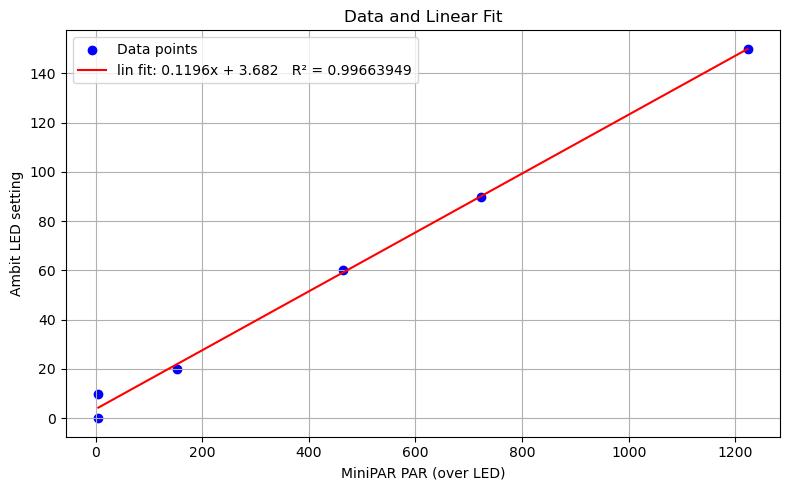

In [10]:
# 4. Ambit LED calibration. 
# Put the ambit in the attachment, put the miniPAR below, the ambit will start to adjust its LED
# and the miniPAR will measure how bright they are.  

LED_CAL_SETTINGS = [10, 20, 60, 90, 150, 0]          # Ambit actinic LED steps
led_setting, measured = [], []
for s in LED_CAL_SETTINGS:
    helpers.set_ambit_led(port_ambit, s)
    time.sleep(0.2)
    measured.append(helpers.get_par_MP(port_miniPAR))
    led_setting.append(s)

x, y = np.array(measured), np.array(led_setting)
coeffs = np.polyfit(x, y, 1)
r2 = helpers.r_squared(y, np.polyval(coeffs, x))
slope = float(coeffs[0])

old = helpers.ambit_reboot(port_ambit).act_led_coeff
print(f"[LED cal] fit slope={slope:.4f}  R^2={r2:.6f}  (current act_led_coeff={old:.4f})")
helpers.plot_data_and_fit(x, y, coeffs, r2,
                            xlabel="MiniPAR PAR (over LED)", ylabel="Ambit LED setting")

In [ ]:
# 5. Ambit PAR calibration.
# Leave the ambit in the same attachement and move the miniPAR to 
# the "higher" position. 
# Normally speaking we use a controlled light source, in this case you will be prompted to go 
# in 3 different light ambient and press enter. 
# Try to have a light as homogenous as possible (outside, or far from the source). 


ref_par, ambit_raw= [], []
for _ in range(3):
    input("Change the intensity of the ambient light and press Enter to continue...")
    time.sleep(1.0)
    ref_par.append(helpers.get_par_MP(port_miniPAR))
    ambit_raw.append(helpers.get_par_AMB(port_ambit, raw=True))
    

x, y = np.array(ambit_raw), np.array(ref_par)
coeffs = np.polyfit(x, y, 1)
r2 = helpers.r_squared(y, np.polyval(coeffs, x))
slope = float(coeffs[0])

old = helpers.ambit_reboot(port_ambit).light_slope
print(f"[PAR cal] fit slope={slope:.4f}  R^2={r2:.6f}  (current light_slope={old:.4f})")
helpers.plot_data_and_fit(x, y, coeffs, r2,
                            xlabel="Ambit PAR (raw)", ylabel="MiniPAR PAR (reference)")


In [33]:
# 6. Finishing steps. 
# Save the calibration payload, try to send it to openJII.

print("\n=== Ambit after calibration ===")
info_postcalibration = helpers.ambit_reboot(port_ambit)
print(info_postcalibration)

print("\n=== Calibration payload ===")
payload = helpers.make_calibration_payload(info_precalibration, info_postcalibration)

print("\n=== Saving payload ===")
save_payload(payload, mac=info_postcalibration.MAC)

try:
    helpers.publish_payload_mqtt5(
        payload,
        topic="experiment/data_ingest/v1/993ae58e-2e87-45ef-96e1-5bbdb0916817/ambit/v1.0/ambit_calibration_1/1234556",
        certs_dir="ambit_calibration_1_certs/ambit_calibration_1_certs",
        endpoint="http://a3qrmjf5m5y241-ats.iot.eu-central-1.amazonaws.com",   # your AWS IoT ATS endpoint
    )
except Exception as e:
    print(f"Failed to publish to MQTT: {e}")


=== Ambit after calibration ===
FW: b'0.0.5' (MAC=48544fa89110, size=544640B, date=Mar  5 2026)
Name: b'AmbitTest', valid: True
Calibration: Spec(light_slope)=0.3, Actinic(act_led_coeff)=100.0, Emit=0.9, Sun=1.0, Temp_offset=0.0, Temp_slope=1.0
Actinic curve: {50: 5, 100: 4, 150: 3, 200: 2, 250: 1}
ADPD cal: [0, 0, 0, 0, 0, 0] (chip v2)
MLX cal: [5822604, 78242704, 0, 6400, 4890169, 5822604, 65971928, -43070208, -37604980, 16384, 0, 10752, 10752, 80119109]
Metadata: {'lon': 1.0, 'lat': 1.0, 'alt': 1.0, 'time': 0, 'acc': 1.0, 'vacc': 1.0, 'info1': 'New_Ambit', 'x': 0.0, 'y': 0.0, 'z': 0.0}

=== Calibration payload ===

=== Saving payload ===
[save] wrote ./calibrations1\2026-06-08_15-27-42_48544fa89110.json
[helpers] MQTT5 connecting to a3qrmjf5m5y241-ats.iot.eu-central-1.amazonaws.com:8883 as ambit_calibration_1_certs ...
[helpers] MQTT5 published 3192 bytes to topic 'experiment/data_ingest/v1/993ae58e-2e87-45ef-96e1-5bbdb0916817/ambit/v1.0/ambit_calibration_1/1234556'
